In [1]:
from plottr.data.datadict_storage import datadict_from_hdf5
import numpy as np
import matplotlib.pyplot as plt
import lmfit
from lmfit.models import GaussianModel
import matplotlib as m

In [2]:
import sklearn
from sklearn.decomposition import PCA

In [3]:
header = "D:/K_sunada/result/CDY154/"
vac = "/2024-01-18/2024-01-18T113131_b0d520eb-80_JPA_vac_squeeze"
# vac = "/2024-01-18/2024-01-18T223334_2da7cfbc-80_JPA_vac_squeeze"
dd = datadict_from_hdf5(header + vac +"/data")

In [4]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

In [6]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

In [7]:
def PCA_transform1(Re_c_amp, Im_c_amp, Re_c_drag, Im_c_drag):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c_amp]).T, np.array([Im_c_amp]).T], axis = 1)
    c1_data = np.concatenate([np.array([Re_c_drag]).T, np.array([Im_c_drag]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    
    c1_pca = pca.transform(c1_data)
    c1_PCA1 = c1_pca.T[0]
    c1_PCA2 = c1_pca.T[1]
    return c_PCA1, c_PCA2, c1_PCA1, c1_PCA2,

ph absorption tomography

In [8]:
import scipy.optimize as op

In [45]:
def fidelity(rhos, theta, ph_num):
    ## target density matrix
    Z2 = 1+ph_num + ph_num**2
    rho_0_tar = np.array([[1, np.sqrt(ph_num)*np.exp(1j*theta)], [np.sqrt(ph_num)*np.exp(-1j*theta), ph_num+ph_num**2/2]])/Z2
    rho_pi_2_tar = np.array([[1, np.sqrt(ph_num)*np.exp(1j*(np.pi/2+theta))], [np.sqrt(ph_num)*np.exp(-1j*(np.pi/2+theta)), ph_num+ph_num**2/2]])/Z2
    rho_pi_tar = np.array([[1, np.sqrt(ph_num)*np.exp(1j*(np.pi+theta))], [np.sqrt(ph_num)*np.exp(-1j*(np.pi+theta)), ph_num+ph_num**2/2]])/Z2
    rho_pi_2_mi_tar = np.array([[1, np.sqrt(ph_num)*np.exp(1j*(-np.pi/2+theta))], [np.sqrt(ph_num)*np.exp(-1j*(-np.pi/2+theta)), ph_num+ph_num**2/2]])/Z2

    F_0 = np.abs(np.trace(np.dot(rho_0_tar, rhos[0])))
    F_pi_2 = np.abs(np.trace(np.dot(rho_pi_2_tar, rhos[1])))
    F_pi = np.abs(np.trace(np.dot(rho_pi_tar, rhos[2])))
    F_pi_2_mi = np.abs(np.trace(np.dot(rho_pi_2_mi_tar, rhos[3])))
    return F_0, F_pi_2, F_pi, F_pi_2_mi, rho_0_tar, rho_pi_2_tar, rho_pi_tar, rho_pi_2_mi_tar

In [46]:
def tomography(data, ph_num):
    ## data acquisition
    dd = datadict_from_hdf5(header + data +"/data")
    signal_x_0 = dd["signal_x_0"]["values"].ravel()
    signal_y_0 = dd["signal_y_0"]["values"].ravel()
    signal_z_0 = dd["signal_z_0"]["values"].ravel()
    signal_x_pi_2 = dd["signal_x_pi_2"]["values"].ravel()
    signal_y_pi_2 = dd["signal_y_pi_2"]["values"].ravel()
    signal_z_pi_2 = dd["signal_z_pi_2"]["values"].ravel()
    signal_x_pi = dd["signal_x_pi"]["values"].ravel()
    signal_y_pi = dd["signal_y_pi"]["values"].ravel()
    signal_z_pi = dd["signal_z_pi"]["values"].ravel()
    signal_x_pi_2_mi = dd["signal_x_pi_2_mi"]["values"].ravel()
    signal_y_pi_2_mi = dd["signal_y_pi_2_mi"]["values"].ravel()
    signal_z_pi_2_mi = dd["signal_z_pi_2_mi"]["values"].ravel()
    
    Ppl_0 = 1- len([el for el in signal_x_0 if el>0.5])/len(signal_x_0)
    Pi_0 = 1- len([el for el in signal_y_0 if el>0.5])/len(signal_y_0)
    Pe_0 = 1- len([el for el in signal_z_0 if el<0.5])/len(signal_z_0)
    Ppl_pi_2 = 1- len([el for el in signal_x_pi_2 if el>0.5])/len(signal_x_pi_2)
    Pi_pi_2 = 1- len([el for el in signal_y_pi_2 if el>0.5])/len(signal_y_pi_2)
    Pe_pi_2 = 1- len([el for el in signal_z_pi_2 if el<0.5])/len(signal_z_pi_2)
    Ppl_pi = 1- len([el for el in signal_x_pi if el>0.5])/len(signal_x_pi)
    Pi_pi = 1- len([el for el in signal_y_pi if el>0.5])/len(signal_y_pi)
    Pe_pi = 1- len([el for el in signal_z_pi if el<0.5])/len(signal_z_pi)
    Ppl_pi_2_mi = 1- len([el for el in signal_x_pi_2_mi if el>0.5])/len(signal_x_pi_2)
    Pi_pi_2_mi = 1- len([el for el in signal_y_pi_2_mi if el>0.5])/len(signal_y_pi_2)
    Pe_pi_2_mi = 1- len([el for el in signal_z_pi_2_mi if el<0.5])/len(signal_z_pi_2)

    ## density matrix from exp.
    sigma_i = np.array([[1, 0], [0, 1]])
    sigma_x =np.array([[0, 1], [1, 0]])
    sigma_y = np.array([[0, -1j], [1j, 0]])
    sigma_z = np.array([[1, 0], [0, -1]])
    rho_0 = (sigma_i + (1-2*Ppl_0) *sigma_x + (1-2*Pi_0) *sigma_y+(1-2*Pe_0) *sigma_z)/2
    rho_pi_2 = (sigma_i + (1-2*Ppl_pi_2) *sigma_x + (1-2*Pi_pi_2) *sigma_y+(1-2*Pe_pi_2) *sigma_z)/2
    rho_pi = (sigma_i + (1-2*Ppl_pi) *sigma_x + (1-2*Pi_pi) *sigma_y+(1-2*Pe_pi) *sigma_z)/2
    rho_pi_2_mi =(sigma_i + (1-2*Ppl_pi_2_mi) *sigma_x + (1-2*Pi_pi_2_mi) *sigma_y+(1-2*Pe_pi_2_mi) *sigma_z)/2
    
    ## theta optimize
    def Fidelity_func(theta):
        return (fidelity([rho_0, rho_pi_2, rho_pi, rho_pi_2_mi], theta, ph_num)[0]+fidelity([rho_0, rho_pi_2, rho_pi, rho_pi_2_mi], theta, ph_num)[1]+fidelity([rho_0, rho_pi_2, rho_pi, rho_pi_2_mi], theta, ph_num)[2]+fidelity([rho_0, rho_pi_2, rho_pi, rho_pi_2_mi], theta, ph_num)[3])/4
    
    theta_temp = np.linspace(0, 2*np.pi, 10000)
    f = 0
    for i in range(len(theta_temp)):
        th = theta_temp[i]
        Fidelity_temp = Fidelity_func(th)
        if f<Fidelity_temp:
            f = Fidelity_temp
            theta = th 
    # theta = op.newton(Fidelity_func, np.pi/2) 
    Fs = fidelity([rho_0, rho_pi_2, rho_pi, rho_pi_2_mi], theta, ph_num)
    return [rho_0, Fs[4], '0', Fs[0], np.trace(Fs[4])], [rho_pi_2, Fs[5], 'pi_2', Fs[1],np.trace(Fs[5])], [rho_pi, Fs[6], 'pi', Fs[2], np.trace(Fs[6])], [rho_pi_2_mi, Fs[7], '-pi_2', Fs[3], np.trace(Fs[7])]

In [47]:
def rho_plot(rho, rho_tar, title):
    x_labels = [r'$|g\rangle$', r'$|e\rangle$']
    y_labels = [r'$|g\rangle$', r'$|e\rangle$']
    fig = plt.figure(figsize=(5,3.5))
    plt.rcParams['figure.figsize'] = [3, 2]
    fig.subplots_adjust(left=-0.1)
    ax = fig.add_subplot(111, projection='3d')
    # ax.set_title(title)
    bar_width = 0.5
    colormap = plt.get_cmap('viridis')
    for i in range(2):
        for j in range(2):
            height = np.abs(rho[i,j])
            height_tar = np.abs(rho_tar[i,j])
            x = i
            y = j
            z = 0
            color = (np.angle(rho[i,j]) + np.pi) / (2 * np.pi)
            # print(np.angle(rho[i,j]))
            ax.bar3d(x, y, z, bar_width, bar_width, height, zorder = 1, color=colormap(color), alpha=1)
            ax.bar3d(x-0.05, y-0.05, z, bar_width+0.1, bar_width+0.1, height_tar,  zorder = 0,color='red',edgecolor='red', alpha=0)

    ax.set_xlim(-0.5, 2)
    ax.set_ylim(-0.5, 2)
    ax.set_zlim(0, 1)

    ax.set_xticks(np.arange(2) + 0.5 * bar_width)
    ax.set_yticks(np.arange(2) + 0.5 * bar_width )
    ax.set_zticks([0, 0.5, 1.0])
    ax.tick_params(axis='z', labelsize=13)
    ax.set_xticklabels(x_labels, fontsize=12)
    ax.set_yticklabels(y_labels, fontsize=12)
    # ax.set_zlabel('Absolute value', labelpad=5, rotation=-90, fontsize=13)
    ax.zaxis.set_rotate_label(False)

    m = plt.cm.ScalarMappable(cmap=colormap)
    m.set_array(np.array([-1, 1]))
    cbar = plt.colorbar(m, shrink=0.7, pad=0.15, ax=ax)  # shrink‚Å'å‚«‚³‚ð¬‚³‚‚µApad‚ÅˆÊ'u‚ð'²®‚·‚é
    # cbar.ax.set_position([0.1, 0, 0.02, 1])
    cbar.set_ticks([-1, -1/2, 0, 1/2, 1])
    cbar.set_ticklabels(['$-\pi$', '$-\pi/2$', '0', '$\pi/2$', '$\pi$'], fontsize=13)
    cbar.set_label('Phase', labelpad=-50, rotation=-90, fontsize=13)
    cbar.ax.yaxis.set_ticks_position('left')
    cbar.ax.yaxis.set_label_position('left')
    # plt.savefig('tr'+title+'.png', bbox_inches='tight')
    # print(rho)

In [48]:
def tomography_rho_plot(data, ph_num):
    rho_0= tomography(data, ph_num)[0]
    rho_pi_2= tomography(data, ph_num)[1]
    rho_pi= tomography(data, ph_num)[2]
    rho_pi_2_mi= tomography(data, ph_num)[3]
    rho_plot(rho_0[0], rho_0[1], rho_0[2])
    rho_plot(rho_pi_2[0], rho_pi_2[1], rho_pi_2[2])
    rho_plot(rho_pi[0], rho_pi[1], rho_pi[2])
    rho_plot(rho_pi_2_mi[0], rho_pi_2_mi[1], rho_pi_2_mi[2])
    print("F_0:",rho_0[3], "F_pi_2:",rho_pi_2[3], "F_pi:",rho_pi[3], "F_pi_2_mi:",rho_pi_2_mi[3],  "F_ave:", (rho_0[3]+rho_pi_2[3]+rho_pi[3]+rho_pi_2_mi[3])/4)

time reverse

F_0: 0.9885016076991849 F_pi_2: 0.9877682658495762 F_pi: 0.9913672820912326 F_pi_2_mi: 0.9796005071811308 F_ave: 0.9868094157052811


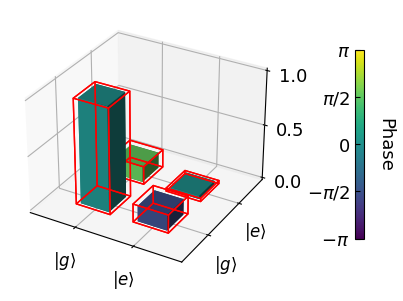

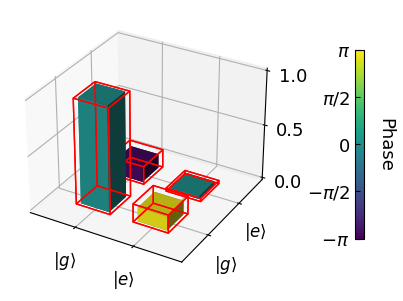

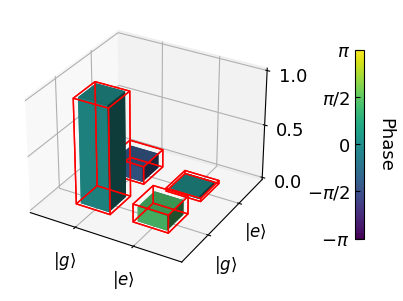

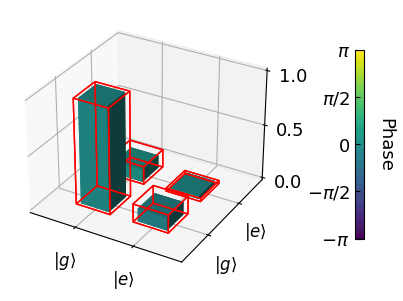

In [49]:
data =  "/2024-01-19/2024-01-19T103228_9b512e8a-86_absoption_tomography"
tomography_rho_plot(data, 0.03)

F_0: 0.9722053087981914 F_pi_2: 0.9718210949874173 F_pi: 0.9702309895708005 F_pi_2_mi: 0.9646009564095739 F_ave: 0.9697145874414959


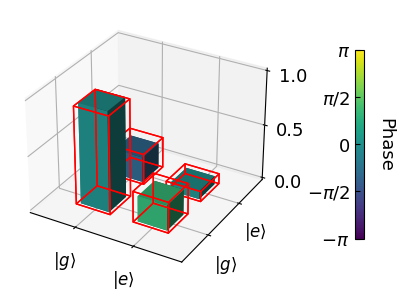

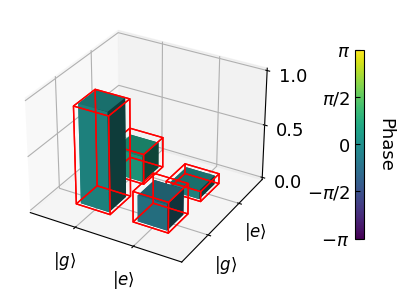

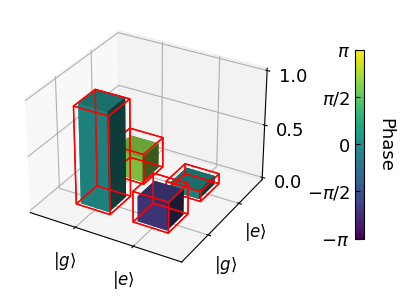

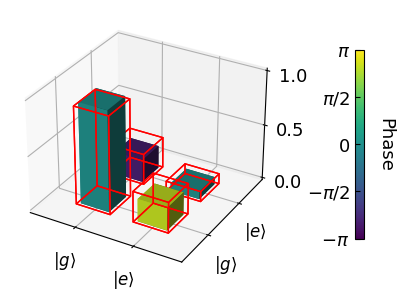

In [50]:
data = "/2024-01-19/2024-01-19T104116_d62ec214-86_absoption_tomography"
tomography_rho_plot(data, 0.1)

F_0: 0.9269104492902662 F_pi_2: 0.9224038758042868 F_pi: 0.9326523485272452 F_pi_2_mi: 0.9260407155412321 F_ave: 0.9270018472907576


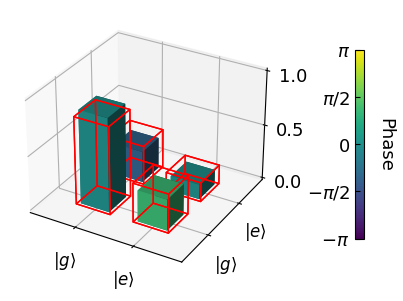

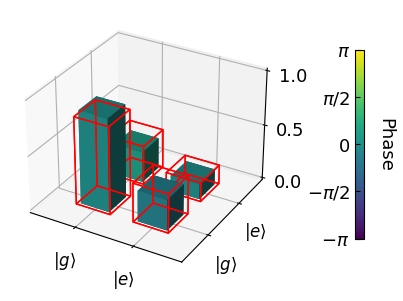

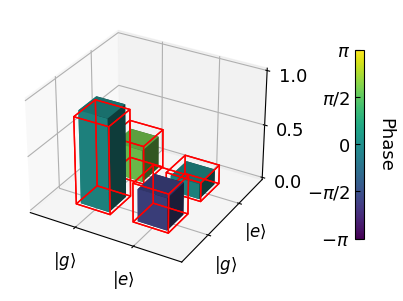

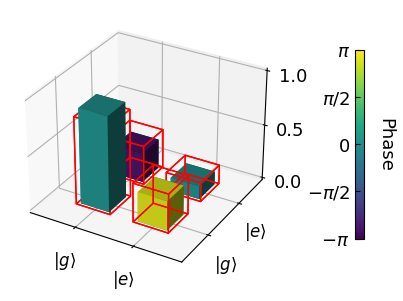

In [51]:
data = "/2024-01-19/2024-01-19T114556_dec68fe7-86_absoption_tomography"
tomography_rho_plot(data, 0.2)

F_0: 0.8748964029975282 F_pi_2: 0.8753307275708812 F_pi: 0.8752041521358233 F_pi_2_mi: 0.8685785227983874 F_ave: 0.8735024513756551


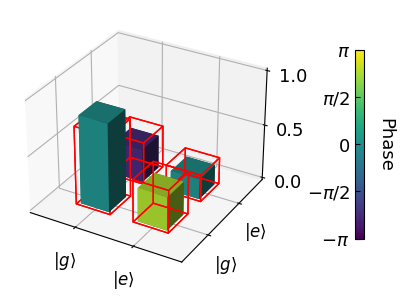

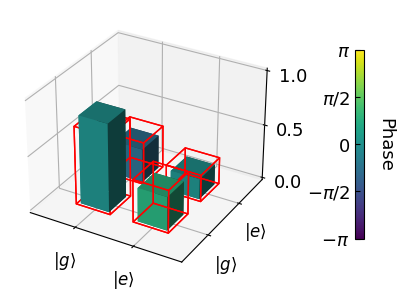

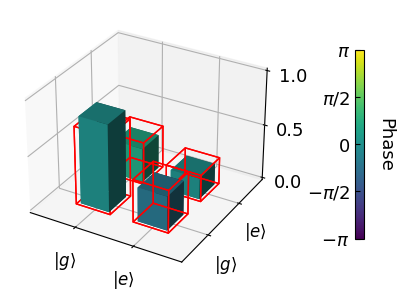

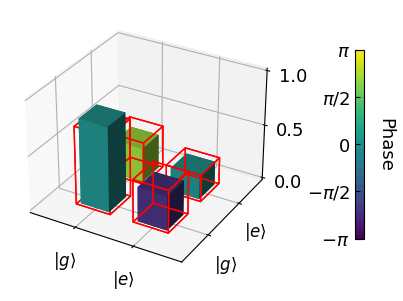

In [52]:
data = "/2024-01-19/2024-01-19T131832_ce4317fa-86_absoption_tomography"
tomography_rho_plot(data, 0.3)

F_0: 0.8291298598415597 F_pi_2: 0.8202015102340282 F_pi: 0.8194917438289427 F_pi_2_mi: 0.7908732617944889 F_ave: 0.8149240939247548


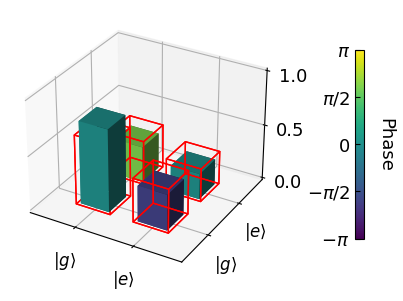

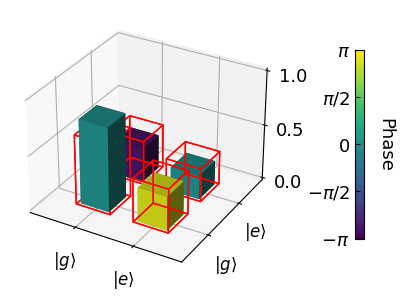

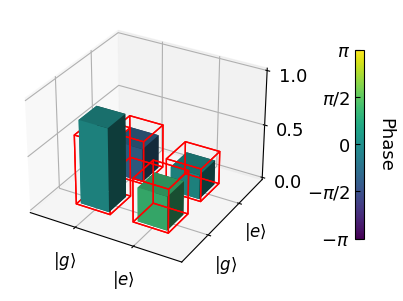

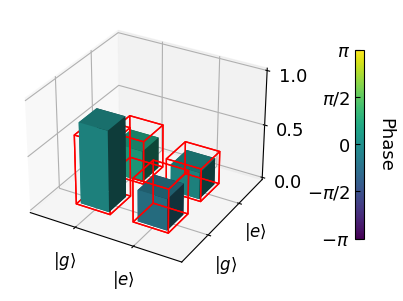

In [53]:
data = "/2024-01-19/2024-01-19T132528_c6327bde-86_absoption_tomography"
tomography_rho_plot(data, 0.4)

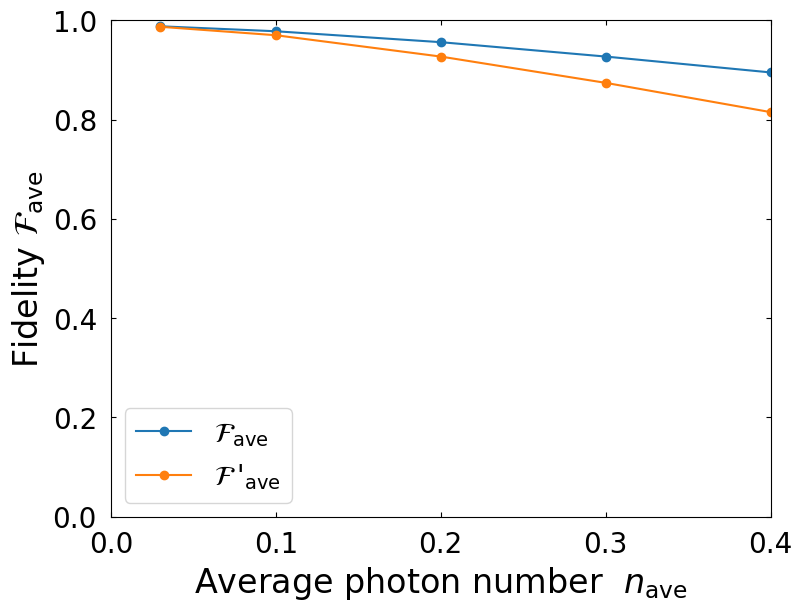

In [62]:
ph_num = [0.03, 0.1, 0.2, 0.3, 0.4]
F_tr = [0.988, 0.978, 0.956, 0.927, 0.895]
F_tr2 = [0.987, 0.970, 0.927, 0.874, 0.815]

fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.tick_params(pad = 10, top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
plt.plot(ph_num, F_tr, 'o-',label = r"$\mathcal{F}_\mathrm{ave}$")
plt.plot(ph_num, F_tr2, 'o-',label = r"$\mathcal{F}\,'_\mathrm{ave}$")
plt.ylim(0., 1)

plt.title("")
plt.legend()
ax.set_xlabel('Average photon number  $n_{\mathrm{ave}}$', size='large')
ax.set_ylabel('Fidelity $\mathcal{F}_{\mathrm{ave}}$', size='large')
ax.set_xlim(0, 0.4)
# plt.savefig('fidelity_2ph.png', bbox_inches='tight')
plt.show()

In [33]:
def fidelity1(rhos, theta, ph_num):
    ## target density matrix
    psi_0 = np.array([1, np.sqrt(ph_num)*np.exp(-1j*theta)]) /np.sqrt((1+ph_num))
    psi_pi_2 = np.array([1, np.sqrt(ph_num)*np.exp(-1j*(-np.pi/2+theta))]) / np.sqrt((1+ph_num))
    psi_pi = np.array([1, np.sqrt(ph_num)*np.exp(-1j*(-np.pi+theta))]) / np.sqrt((1+ph_num))
    psi_pi_2_mi = np.array([1, np.sqrt(ph_num)*np.exp(-1j*(np.pi/2+theta))]) / np.sqrt((1+ph_num))

    rho_0_tar = np.outer(psi_0, psi_0.conj())
    rho_pi_2_tar = np.outer(psi_pi_2, psi_pi_2.conj())
    rho_pi_tar = np.outer(psi_pi, psi_pi.conj())
    rho_pi_2_mi_tar = np.outer(psi_pi_2_mi, psi_pi_2_mi.conj())

    F_0 = np.abs(np.trace(np.dot(rho_0_tar, rhos[0])))
    F_pi_2 = np.abs(np.trace(np.dot(rho_pi_2_tar, rhos[1])))
    F_pi = np.abs(np.trace(np.dot(rho_pi_tar, rhos[2])))
    F_pi_2_mi = np.abs(np.trace(np.dot(rho_pi_2_mi_tar, rhos[3])))
    return F_0, F_pi_2, F_pi, F_pi_2_mi, rho_0_tar, rho_pi_2_tar, rho_pi_tar, rho_pi_2_mi_tar

In [34]:
def tomography1(data, ph_num):
    ## data acquisition
    dd = datadict_from_hdf5(header + data +"/data")
    signal_x_0 = dd["signal_x_0"]["values"].ravel()
    signal_y_0 = dd["signal_y_0"]["values"].ravel()
    signal_z_0 = dd["signal_z_0"]["values"].ravel()
    signal_x_pi_2 = dd["signal_x_pi_2"]["values"].ravel()
    signal_y_pi_2 = dd["signal_y_pi_2"]["values"].ravel()
    signal_z_pi_2 = dd["signal_z_pi_2"]["values"].ravel()
    signal_x_pi = dd["signal_x_pi"]["values"].ravel()
    signal_y_pi = dd["signal_y_pi"]["values"].ravel()
    signal_z_pi = dd["signal_z_pi"]["values"].ravel()
    signal_x_pi_2_mi = dd["signal_x_pi_2_mi"]["values"].ravel()
    signal_y_pi_2_mi = dd["signal_y_pi_2_mi"]["values"].ravel()
    signal_z_pi_2_mi = dd["signal_z_pi_2_mi"]["values"].ravel()
    
    Ppl_0 = 1- len([el for el in signal_x_0 if el>0.5])/len(signal_x_0)
    Pi_0 = 1- len([el for el in signal_y_0 if el>0.5])/len(signal_y_0)
    Pe_0 = 1- len([el for el in signal_z_0 if el<0.5])/len(signal_z_0)
    Ppl_pi_2 = 1- len([el for el in signal_x_pi_2 if el>0.5])/len(signal_x_pi_2)
    Pi_pi_2 = 1- len([el for el in signal_y_pi_2 if el>0.5])/len(signal_y_pi_2)
    Pe_pi_2 = 1- len([el for el in signal_z_pi_2 if el<0.5])/len(signal_z_pi_2)
    Ppl_pi = 1- len([el for el in signal_x_pi if el>0.5])/len(signal_x_pi)
    Pi_pi = 1- len([el for el in signal_y_pi if el>0.5])/len(signal_y_pi)
    Pe_pi = 1- len([el for el in signal_z_pi if el<0.5])/len(signal_z_pi)
    Ppl_pi_2_mi = 1- len([el for el in signal_x_pi_2_mi if el>0.5])/len(signal_x_pi_2)
    Pi_pi_2_mi = 1- len([el for el in signal_y_pi_2_mi if el>0.5])/len(signal_y_pi_2)
    Pe_pi_2_mi = 1- len([el for el in signal_z_pi_2_mi if el<0.5])/len(signal_z_pi_2)

    ## density matrix from exp.
    sigma_i = np.array([[1, 0], [0, 1]])
    sigma_x =np.array([[0, 1], [1, 0]])
    sigma_y = np.array([[0, -1j], [1j, 0]])
    sigma_z = np.array([[1, 0], [0, -1]])
    rho_0 = (sigma_i + (1-2*Ppl_0) *sigma_x + (1-2*Pi_0) *sigma_y+(1-2*Pe_0) *sigma_z)/2
    rho_pi_2 = (sigma_i + (1-2*Ppl_pi_2) *sigma_x + (1-2*Pi_pi_2) *sigma_y+(1-2*Pe_pi_2) *sigma_z)/2
    rho_pi = (sigma_i + (1-2*Ppl_pi) *sigma_x + (1-2*Pi_pi) *sigma_y+(1-2*Pe_pi) *sigma_z)/2
    rho_pi_2_mi =(sigma_i + (1-2*Ppl_pi_2_mi) *sigma_x + (1-2*Pi_pi_2_mi) *sigma_y+(1-2*Pe_pi_2_mi) *sigma_z)/2
    
    ## theta optimize
    def Fidelity_func(theta):
        return (fidelity1([rho_0, rho_pi_2, rho_pi, rho_pi_2_mi], theta, ph_num)[0]+fidelity1([rho_0, rho_pi_2, rho_pi, rho_pi_2_mi], theta, ph_num)[1]+fidelity1([rho_0, rho_pi_2, rho_pi, rho_pi_2_mi], theta, ph_num)[2]+fidelity1([rho_0, rho_pi_2, rho_pi, rho_pi_2_mi], theta, ph_num)[3])/4
    
    theta_temp = np.linspace(0, 2*np.pi, 10000)
    f = 0
    for i in range(len(theta_temp)):
        th = theta_temp[i]
        Fidelity_temp = Fidelity_func(th)
        if f<Fidelity_temp:
            f = Fidelity_temp
            theta = th 
    # theta = op.newton(Fidelity_func, np.pi/2) 
    Fs = fidelity1([rho_0, rho_pi_2, rho_pi, rho_pi_2_mi], theta, ph_num)
    return [rho_0, Fs[4], '0', Fs[0]], [rho_pi_2, Fs[5], 'pi_2', Fs[1]], [rho_pi, Fs[6], 'pi', Fs[2]], [rho_pi_2_mi, Fs[6], '-pi_2', Fs[3]]

In [35]:
def tomography_rho_plot1(data, ph_num):
    rho_0= tomography1(data, ph_num)[0]
    rho_pi_2= tomography1(data, ph_num)[1]
    rho_pi= tomography1(data, ph_num)[2]
    rho_pi_2_mi= tomography1(data, ph_num)[3]
    rho_plot(rho_0[0], rho_0[1], rho_0[2])
    rho_plot(rho_pi_2[0], rho_pi_2[1], rho_pi_2[2])
    rho_plot(rho_pi[0], rho_pi[1], rho_pi[2])
    rho_plot(rho_pi_2_mi[0], rho_pi_2_mi[1], rho_pi_2_mi[2])
    print("F_0:",rho_0[3], "F_pi_2:",rho_pi_2[3], "F_pi:",rho_pi[3], "F_pi_2_mi:",rho_pi_2_mi[3], "F_ave:", (rho_0[3]+rho_pi_2[3]+rho_pi[3]+rho_pi_2_mi[3])/4)

time-unreverse

F_0: 0.9742672233097696 F_pi_2: 0.9701103367757149 F_pi: 0.9774288653466985 F_pi_2_mi: 0.9866698823568516 F_ave: 0.9771190769472586


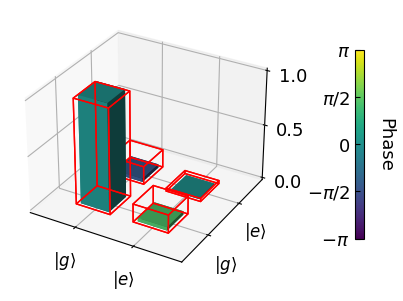

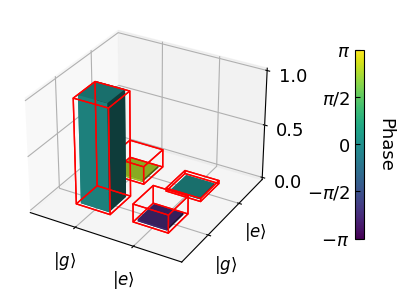

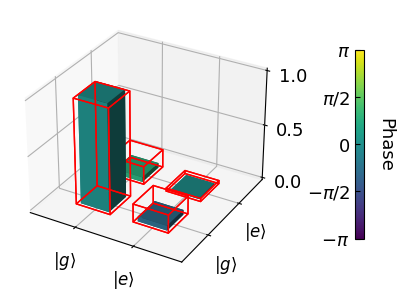

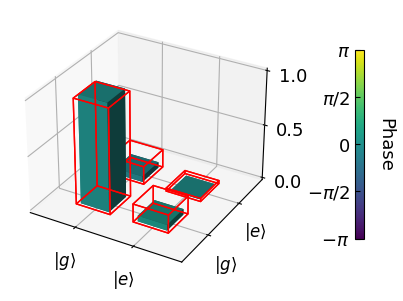

In [36]:
data = "/2024-01-19/2024-01-19T141641_ee058608-86_absoption_tomography"
tomography_rho_plot1(data, 0.03)

F_0: 0.9335213098977154 F_pi_2: 0.9458106734237887 F_pi: 0.9356918037261378 F_pi_2_mi: 0.9244719379227935 F_ave: 0.9348739312426089


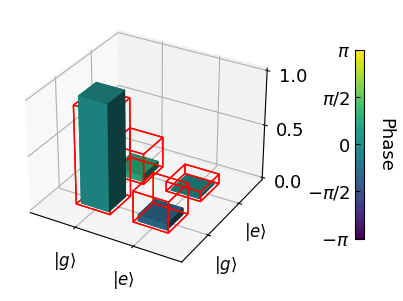

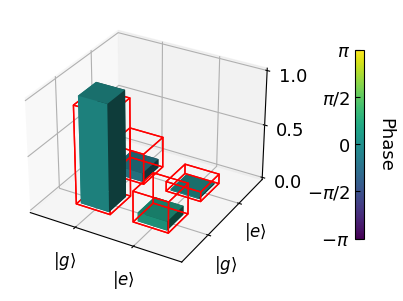

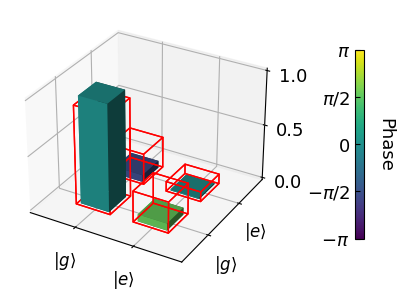

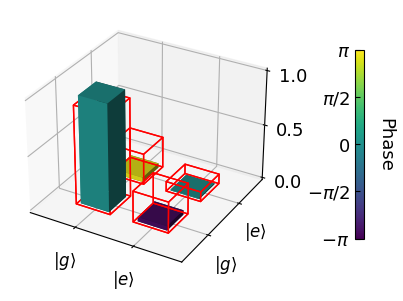

In [37]:
data = "/2024-01-19/2024-01-19T143852_07367702-86_absoption_tomography"
tomography_rho_plot1(data, 0.1)

F_0: 0.8952866471605759 F_pi_2: 0.8822655189880398 F_pi: 0.8773844045262392 F_pi_2_mi: 0.8783137846601938 F_ave: 0.8833125888337623


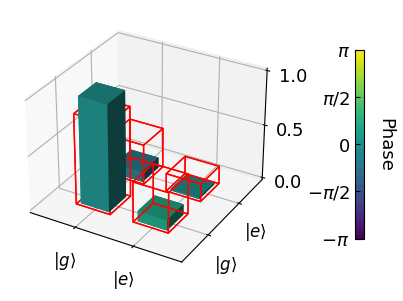

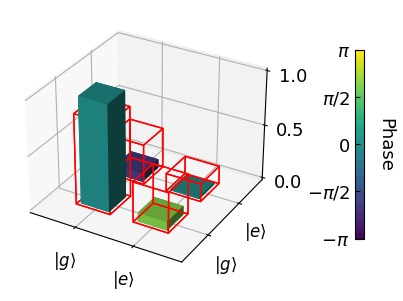

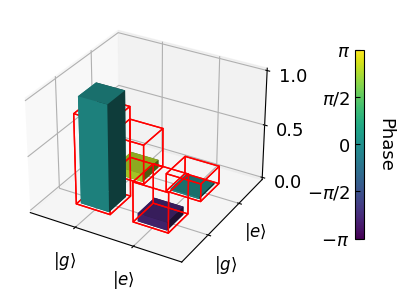

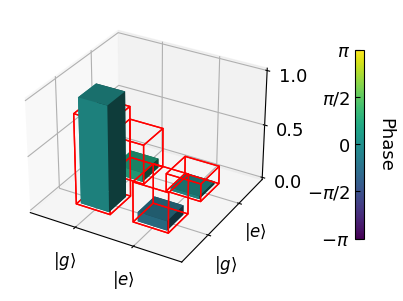

In [38]:
data = "/2024-01-22/2024-01-22T121146_f9faab85-86_absoption_tomography"
tomography_rho_plot1(data, 0.2)

F_0: 0.8351506411840649 F_pi_2: 0.824849112662095 F_pi: 0.8424959657320017 F_pi_2_mi: 0.8310870252124778 F_ave: 0.8333956861976599


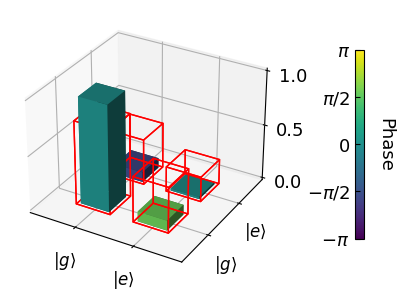

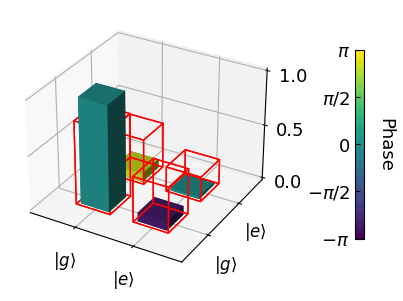

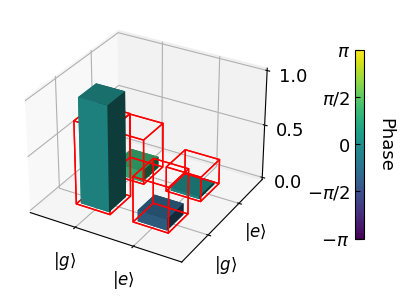

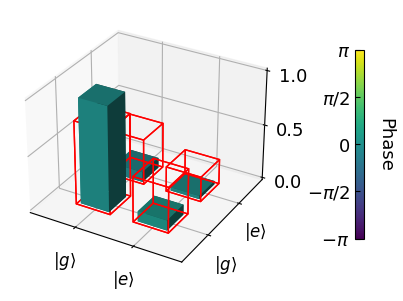

In [39]:
data = "/2024-01-19/2024-01-19T145350_1edd4fc4-86_absoption_tomography"
tomography_rho_plot1(data, 0.3)

F_0: 0.7828389036977093 F_pi_2: 0.7988565776103155 F_pi: 0.8162790053826265 F_pi_2_mi: 0.795194050932231 F_ave: 0.7982921344057206


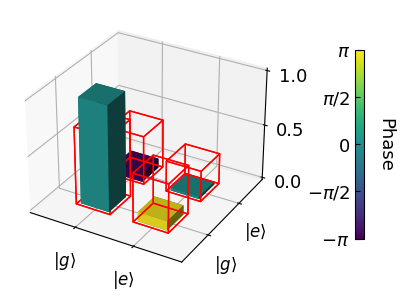

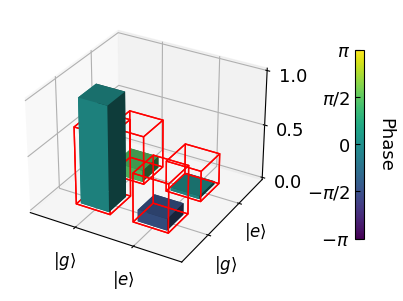

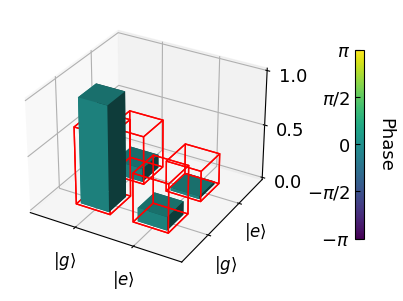

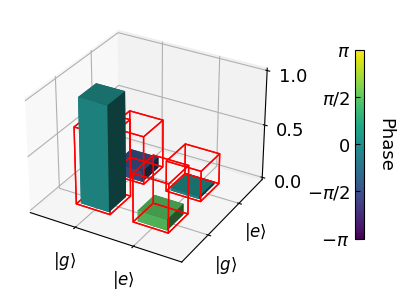

In [40]:
data = "/2024-01-19/2024-01-19T150906_4093318d-86_absoption_tomography"
tomography_rho_plot1(data, 0.4)

square

F_0: 0.983917604736824 F_pi_2: 0.9867468871843518 F_pi: 0.9801104686511121 F_pi_2_mi: 0.9793757653695605 F_ave: 0.9825376814854621


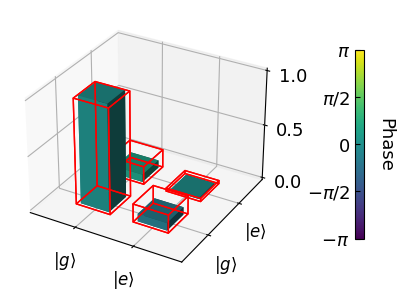

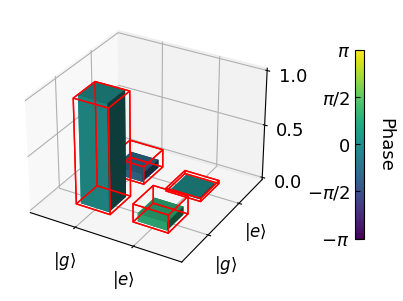

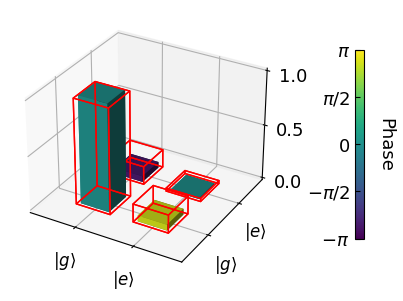

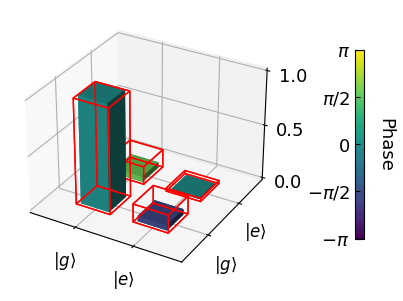

In [41]:
data = "/2024-01-19/2024-01-19T152931_1a9a697c-86_absoption_tomography"
tomography_rho_plot1(data, 0.03)

F_0: 0.9537271138062813 F_pi_2: 0.9668765100393011 F_pi: 0.9612964370356185 F_pi_2_mi: 0.9478237194204642 F_ave: 0.9574309450754163


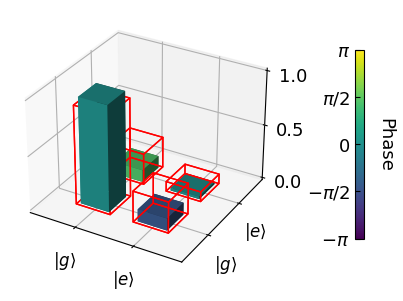

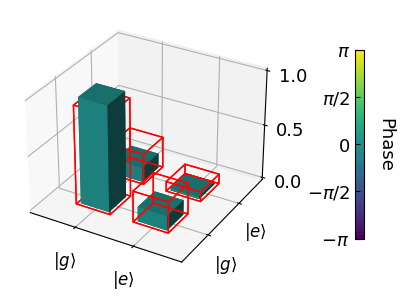

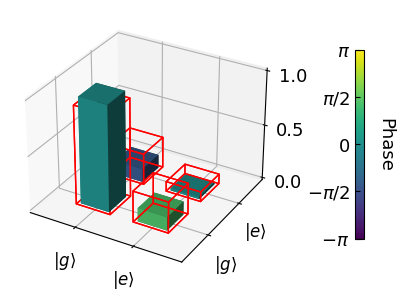

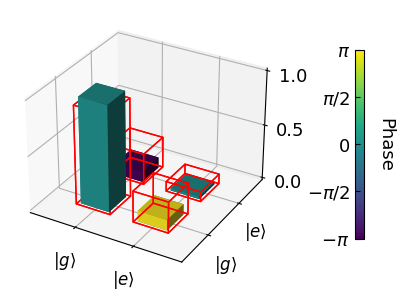

In [42]:
data = "/2024-01-19/2024-01-19T154525_539ac6cc-86_absoption_tomography"
tomography_rho_plot1(data, 0.1)

F_0: 0.9143687517491349 F_pi_2: 0.9335372881612135 F_pi: 0.9365278980095413 F_pi_2_mi: 0.9176887147285298 F_ave: 0.9255306631621049


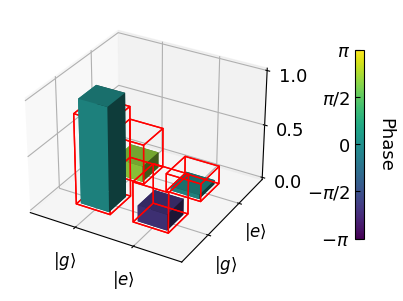

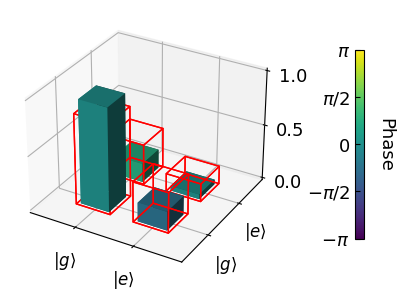

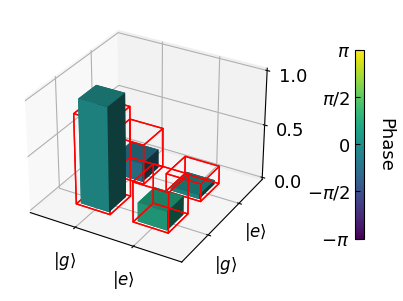

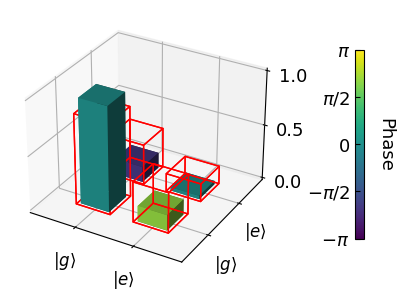

In [43]:
data ="/2024-01-19/2024-01-19T160055_7dbcf5dd-86_absoption_tomography"
tomography_rho_plot1(data, 0.2)

F_0: 0.9099533822822232 F_pi_2: 0.9027898868082797 F_pi: 0.8897563765011244 F_pi_2_mi: 0.8946740176931662 F_ave: 0.8992934158211984


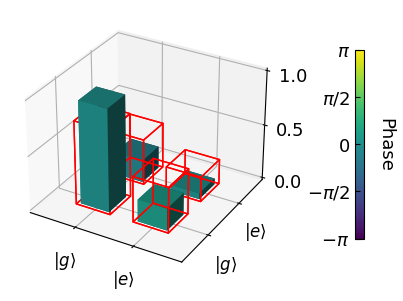

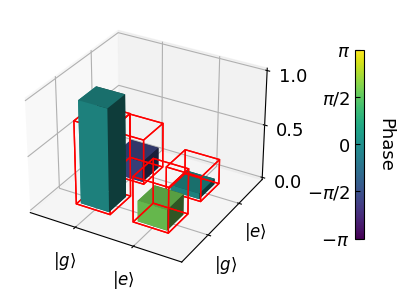

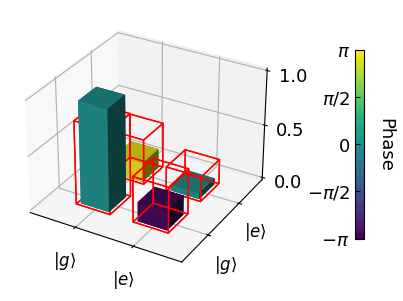

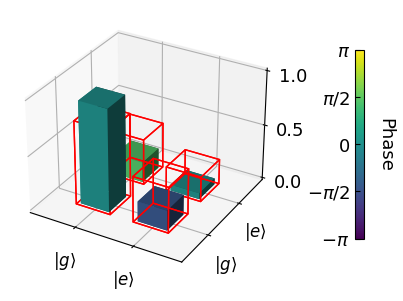

In [44]:
data = "/2024-01-19/2024-01-19T161658_bbd027ef-86_absoption_tomography"
tomography_rho_plot1(data, 0.3)

F_0: 0.878590796084036 F_pi_2: 0.8649320021957514 F_pi: 0.8708697307755574 F_pi_2_mi: 0.8679886528898151 F_ave: 0.87059529548629


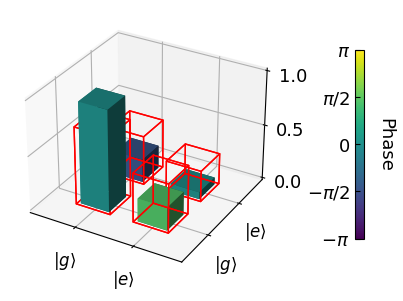

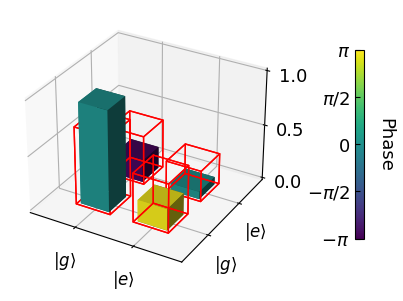

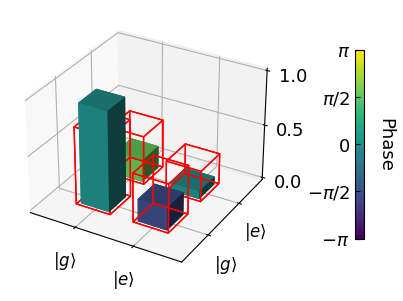

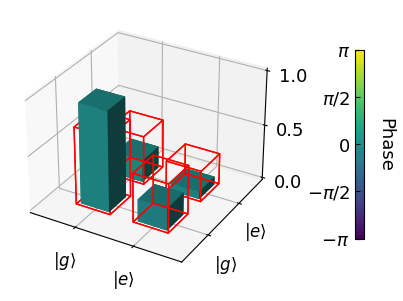

In [45]:
data = "/2024-01-19/2024-01-19T165104_7efae32c-86_absoption_tomography"
tomography_rho_plot1(data, 0.4)

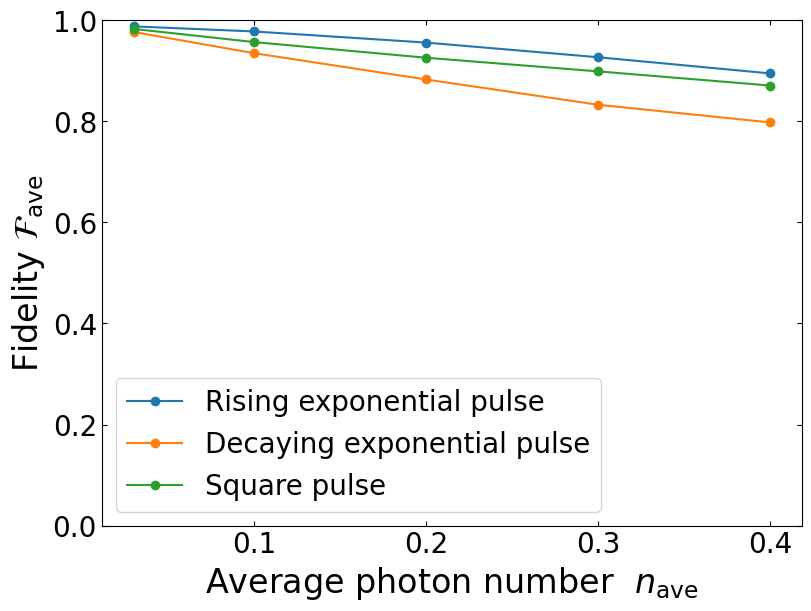

In [46]:
ph_num = [0.03, 0.1, 0.2, 0.3, 0.4]
F_tr = [0.988, 0.978, 0.956, 0.927, 0.895]
F_utr = [0.977, 0.935, 0.883, 0.833, 0.798]
F_sq = [0.983, 0.957, 0.926, 0.899, 0.871]

fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
plt.plot(ph_num, F_tr, 'o-',label = "Rising exponential pulse")
plt.plot(ph_num, F_utr, 'o-',label = "Decaying exponential pulse")
plt.plot(ph_num, F_sq,'o-', label = "Square pulse")
plt.ylim(0., 1)

plt.title("")
plt.legend()
ax.set_xlabel('Average photon number  $n_{\mathrm{ave}}$', size='large')
ax.set_ylabel('Fidelity $\mathcal{F}_{\mathrm{ave}}$', size='large')
# plt.savefig('fidelity_summary.png', bbox_inches='tight')
plt.show()